# 5.3.- Transfer Learning con MobileNetV2 y Fine Tuning

En este notebook se aplicará **Transfer Learning** utilizando la arquitectura preentrenada **MobileNetV2**, un modelo eficiente y estable entrenado originalmente en *ImageNet*.

El objetivo es reutilizar sus características para resolver el problema de clasificación del dataset **CIFAR-10**, realizando además un proceso de **Fine Tuning** en las capas superiores.

### Etapas principales
1. Carga del dataset CIFAR-10 y creación de *ImageDataGenerator*.  
2. Construcción del modelo base con *MobileNetV2*.  
3. Entrenamiento inicial (Transfer Learning).  
4. Fine Tuning del modelo.  
5. Evaluación final y visualización de resultados.

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(33)
tf.random.set_seed(33)

## Carga del dataset CIFAR-10 y preparación a 64×64

Para utilizar **MobileNetV2** con el dataset **CIFAR-10**, las imágenes originales (32×32) se redimensionarán a **64×64 píxeles**.  
Este tamaño intermedio permite mantener la nitidez suficiente para que el modelo aproveche los filtros convolucionales preentrenados en *ImageNet*, sin aumentar en exceso el coste computacional.

### Normalización
Las imágenes de CIFAR-10 tienen valores de píxel en el rango `[0, 255]`.  
Se normalizan dividiendo cada valor por 255 (`rescale=1./255`),  
lo que mejora la estabilidad numérica del entrenamiento y evita gradientes explosivos.

### Data Augmentation
Durante el entrenamiento, se aplican ligeras transformaciones aleatorias a las imágenes para aumentar la diversidad de datos y reducir el *overfitting*.  
En particular:

- **`rotation_range=15`** → pequeñas rotaciones aleatorias.  
- **`width_shift_range` y `height_shift_range`** → desplazamientos horizontales y verticales (10%).  
- **`horizontal_flip=True`** → inversión horizontal aleatoria.  
- **`validation_split=0.1`** → separación automática del 10% del conjunto de entrenamiento para validación.

Estas transformaciones permiten que el modelo generalice mejor sin necesidad de recopilar más imágenes.

In [15]:
# Cargar dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
num_classes = 10

# Redimensionar a 64x64
def resize_images(images, size=(64, 64)):
    images_resized = tf.image.resize(images, size)
    return images_resized.numpy()

X_train = resize_images(X_train)
X_test = resize_images(X_test)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Generadores
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow(X_train, y_train, batch_size=32, subset='training', seed=42)
val_gen = train_datagen.flow(X_train, y_train, batch_size=32, subset='validation', seed=42)
test_gen = test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

## Construcción del modelo con MobileNetV2

En esta sección se construye el modelo utilizando la API **Sequential** de Keras y la arquitectura preentrenada **MobileNetV2**.

Se empleará **MobileNetV2** como base convolucional, preentrenada sobre *ImageNet*, adaptada a la nueva resolución de **64×64×3**.

En la primera fase, el modelo base estará **congelado** y solo se entrenará la cabeza de clasificación.

### Arquitectura del modelo
1. **MobileNetV2** preentrenado en *ImageNet* (congelado).  
2. **GlobalAveragePooling2D** → reduce la dimensionalidad.  
3. **Dense(256, ReLU)** + *Dropout(0.4)* → cabeza de clasificación.  
4. **Dense(10, Softmax)** → salida multiclase (CIFAR-10).

In [16]:
# Cargar modelo base adaptado a 64x64
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(64, 64, 3))

# Transfer learning
base_model.trainable = False

model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_7155/2279281717.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(64, 64, 3))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## Entrenamiento inicial — Transfer Learning

Durante esta fase se entrena solo la parte superior del modelo (las capas densas añadidas),  
mientras que el bloque convolucional de **MobileNetV2** permanece congelado.

Esto permite adaptar el clasificador a CIFAR-10 sin modificar los pesos preentrenados en *ImageNet*.

In [17]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
    ModelCheckpoint('mobilenetv2_transfer.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_transfer = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4736 - loss: 1.6399 - val_accuracy: 0.6098 - val_loss: 1.1225 - learning_rate: 0.0010
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.5765 - loss: 1.2120 - val_accuracy: 0.6086 - val_loss: 1.1062 - learning_rate: 0.0010
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.5951 - loss: 1.1610 - val_accuracy: 0.6252 - val_loss: 1.0866 - learning_rate: 0.0010
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6016 - loss: 1.1312 - val_accuracy: 0.6190 - val_loss: 1.0805 - learning_rate: 0.0010
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6016 - loss: 1.1294 - val_accuracy: 0.6368 - val_loss: 1.0541 - learning_rate: 0.0010
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.6119 - loss: 1.1096 - val_accuracy: 0.6218 - val_loss: 1.0640 - learning_rate: 0.0010
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accura

## Fine Tuning del modelo

En esta segunda fase del entrenamiento se realiza el **Fine Tuning** de MobileNetV2.  
Esto consiste en descongelar las capas superiores del modelo base y reentrenarlas junto con la cabeza de clasificación,  
para adaptar mejor los pesos preentrenados al dominio del dataset CIFAR-10.

### Estrategia aplicada
1. Descongelar las **últimas capas** del modelo base (mantener las iniciales congeladas).  
2. Usar una **tasa de aprendizaje más baja** (por ejemplo, `1e-4`) para no destruir los pesos preentrenados.  
3. Continuar el entrenamiento con `ReduceLROnPlateau`, `EarlyStopping` y `ModelCheckpoint`.

In [18]:
# Descongelar parte de MobileNetV2 (por ejemplo, las últimas 50 capas)
base_model = model.layers[0]  # MobileNetV2 está en la primera posición del Sequential
base_model.trainable = True

# Congelar las capas inferiores
for layer in base_model.layers[:-50]:
    layer.trainable = False

print(f"Número de capas entrenables: {len([l for l in base_model.layers if l.trainable])}")

# Compilar de nuevo con un LR más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Número de capas entrenables: 50


## Entrenamiento del modelo — Fine Tuning

Durante esta fase, las capas superiores de **MobileNetV2** se ajustan finamente al dataset CIFAR-10.  
Esto mejora la capacidad del modelo para reconocer patrones específicos del nuevo dominio,  
mientras que las capas inferiores mantienen el conocimiento general de las imágenes naturales aprendido en *ImageNet*.

In [19]:
callbacks_fine = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
    ModelCheckpoint('mobilenetv2_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_fine,
    verbose=1
)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.4430 - loss: 1.6768 - val_accuracy: 0.6112 - val_loss: 1.1048 - learning_rate: 1.0000e-05
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.5524 - loss: 1.3002 - val_accuracy: 0.6328 - val_loss: 1.0559 - learning_rate: 1.0000e-05
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6028 - loss: 1.1560 - val_accuracy: 0.6642 - val_loss: 0.9899 - learning_rate: 1.0000e-05
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.6293 - loss: 1.0684 - val_accuracy: 0.6852 - val_loss: 0.9066 - learning_rate: 1.0000e-05
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6508 - loss: 1.0025 - val_accuracy: 0.7100 - val_loss: 0.8534 - learning_rate: 1.0000e-05
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.6724 - loss: 0.9395 - val_accuracy: 0.7170 - val_loss: 0.8182 - learning_rate: 1.0000e-05
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━

## Evaluación del modelo Fine-Tuned

Una vez completado el Fine Tuning, se evalúa el rendimiento del modelo sobre el conjunto de prueba.  
Se muestran las métricas de pérdida (*loss*) y exactitud (*accuracy*),  
además de las curvas de entrenamiento para analizar la evolución durante ambas fases:  
- Transfer Learning (modelo base congelado)  
- Fine Tuning (modelo parcialmente descongelado)

Accuracy en test: 0.8376
Pérdida en test: 0.4654


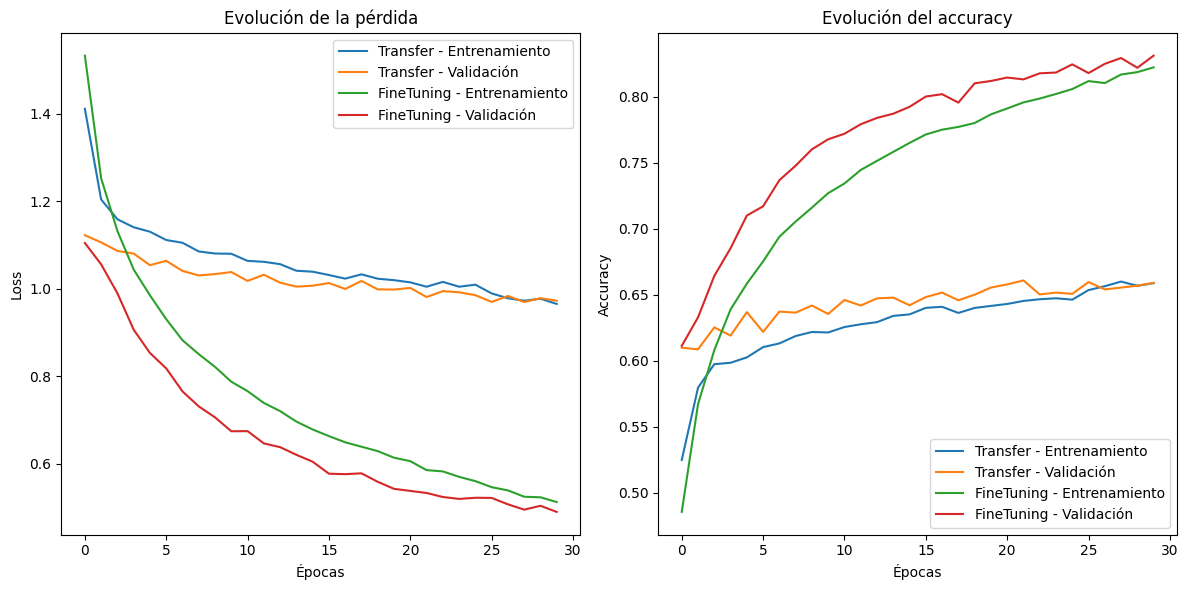

In [20]:
# Evaluación final sobre el conjunto de prueba
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Accuracy en test: {test_acc:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")

# Visualización de las curvas de aprendizaje combinadas
# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['loss'], label='Transfer - Entrenamiento')
plt.plot(history_transfer.history['val_loss'], label='Transfer - Validación')
plt.plot(history_fine.history['loss'], label='FineTuning - Entrenamiento')
plt.plot(history_fine.history['val_loss'], label='FineTuning - Validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['accuracy'], label='Transfer - Entrenamiento')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer - Validación')
plt.plot(history_fine.history['accuracy'], label='FineTuning - Entrenamiento')
plt.plot(history_fine.history['val_accuracy'], label='FineTuning - Validación')
plt.title('Evolución del accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Matriz de confusión

Para analizar más a fondo el rendimiento del modelo,  
se genera una **matriz de confusión** que permite observar en qué clases el modelo acierta o se confunde más.

Esto ayuda a identificar patrones de error y posibles mejoras futuras.

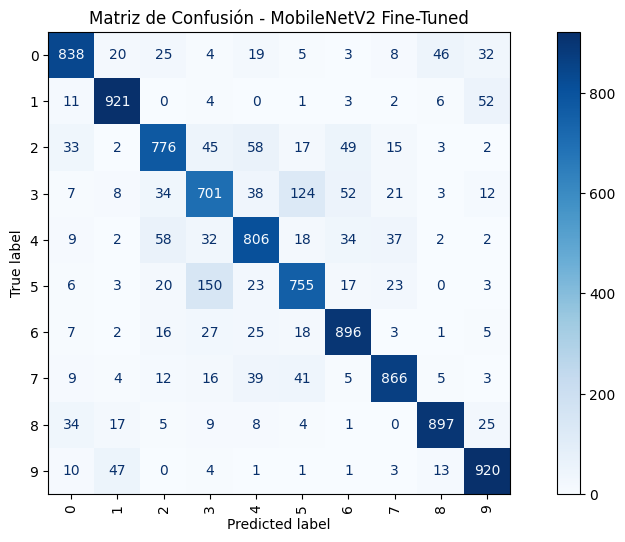

In [21]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(test_gen, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Matriz de Confusión - MobileNetV2 Fine-Tuned")
plt.show()